# Multidimensional GBM Monte Carlo for Discounted Cash Flow

This notebook is ordered so you can plug in:

1. your stochastic drivers
2. your covariance matrix
3. your discounted cash flow function

The core idea is:

- simulate correlated Brownian shocks using the covariance matrix
- evolve all stochastic drivers jointly under a multidimensional GBM
- apply your discounted cash flow function to each simulated path


In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Define simulation inputs

Keep all user-editable assumptions in one place.


In [96]:
# Basic Monte Carlo settings
n_assets = 4
n_sims = 10_000
n_steps = 18
T = 18.0
dt = T / n_steps

# Keep the driver order fixed throughout the notebook
asset_names = [
    "price_of_ibap",
    "ibap_throughput",
    "price_of_HF",
    "HF_throughput",
]

# Initial values S(0)
S0 = np.array([
    1.9699,
    6629568,
    0.405,
    3376704,
])

# Annualized drifts mu
mu = np.array([
    1,
    1,
    1,
    1,
])

raw_material_cost = 24684382
inflation = 0.02
discount_rate = 0.1

# Annualized covariance matrix of the GBM drivers
# Replace this with your own covariance matrix
cov_matrix = np.array([
    [0.017536, 0, 0.001032, 0],
    [0, 0.01, 0, 0],
    [0.001032, 0, 0.000804, 0],
    [0, 0, 0, 0.1],
], dtype=float)

assert len(S0) == n_assets
assert len(mu) == n_assets
assert cov_matrix.shape == (n_assets, n_assets)

## 2. Validate covariance matrix

This helps catch dimension errors and non-positive semidefinite inputs early.


In [97]:
def validate_covariance_matrix(cov):
    cov = np.asarray(cov, dtype=float)

    if cov.ndim != 2 or cov.shape[0] != cov.shape[1]:
        raise ValueError("cov_matrix must be square.")

    if not np.allclose(cov, cov.T, atol=1e-10):
        raise ValueError("cov_matrix must be symmetric.")

    eigenvalues = np.linalg.eigvalsh(cov)
    if np.min(eigenvalues) < -1e-10:
        raise ValueError("cov_matrix must be positive semidefinite.")

    return eigenvalues


eigenvalues = validate_covariance_matrix(cov_matrix)
vols = np.sqrt(np.diag(cov_matrix))
corr_matrix = cov_matrix / np.outer(vols, vols)

print("Eigenvalues:", eigenvalues)
print("Volatilities:", vols)
print("Correlation matrix:\n", corr_matrix)

Eigenvalues: [0.00074059 0.01       0.01759941 0.1       ]
Volatilities: [0.13242356 0.1        0.02835489 0.31622777]
Correlation matrix:
 [[1.         0.         0.27484409 0.        ]
 [0.         1.         0.         0.        ]
 [0.27484409 0.         1.         0.        ]
 [0.         0.         0.         1.        ]]


## 3. Multidimensional GBM simulator

The update rule is:

$$S_{t+\Delta t}^{(i)} = S_t^{(i)} \exp\left((\mu_i - 0.5\sigma_i^2)\Delta t + \Delta W_i\right)$$

where the correlated increment vector satisfies:

$$\Delta W \sim \mathcal{N}(0, \Sigma \Delta t)$$

and `cov_matrix = Sigma`.


In [98]:
def simulate_multidim_gbm(S0, mu, cov_matrix, asset_names, T, n_steps, n_sims, random_seed=42):
    S0 = np.asarray(S0, dtype=float)
    mu = np.asarray(mu, dtype=float)
    cov_matrix = np.asarray(cov_matrix, dtype=float)
    asset_names = list(asset_names)

    n_assets = len(S0)
    dt = T / n_steps

    if len(mu) != n_assets:
        raise ValueError("mu must have the same length as S0.")

    if len(asset_names) != n_assets:
        raise ValueError("asset_names must have the same length as S0.")

    validate_covariance_matrix(cov_matrix)

    if cov_matrix.shape != (n_assets, n_assets):
        raise ValueError("cov_matrix dimensions must match the number of stochastic drivers.")

    rng = np.random.default_rng(random_seed)

    # Use an eigenvalue factorization to remain stable even if the matrix
    # is only positive semidefinite.
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    cov_sqrt = eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T

    z = rng.normal(size=(n_sims, n_steps, n_assets))
    dW = np.sqrt(dt) * np.einsum("tka,ab->tkb", z, cov_sqrt)

    variances = np.diag(cov_matrix)
    drift_term = (mu - 0.5 * variances) * dt

    log_returns = drift_term[None, None, :] + dW

    log_paths = np.zeros((n_sims, n_steps + 1, n_assets), dtype=float)
    log_paths[:, 0, :] = np.log(S0)
    log_paths[:, 1:, :] = np.log(S0)[None, None, :] + np.cumsum(log_returns, axis=1)

    paths = np.exp(log_paths)

    return {
        name: paths[:, :, idx]
        for idx, name in enumerate(asset_names)
    }

## 4. Define the discounted cash flow function

The simulator now returns a dictionary whose keys are your stochastic driver names.

For example:

- `simulated_paths["price_of_ibap"]`
- `simulated_paths["ibap_throughput"]`
- `simulated_paths["price_of_HF"]`
- `simulated_paths["HF_throughput"]`


In [99]:
def calculate_discounted_cash_flows(simulated_paths, raw_material_cost, inflation, discount_rate):
    price_of_ibap = simulated_paths["price_of_ibap"]
    ibap_throughput = simulated_paths["ibap_throughput"]
    price_of_HF = simulated_paths["price_of_HF"]
    HF_throughput = simulated_paths["HF_throughput"]

    t = np.arange(price_of_ibap.shape[1])

    revenue = price_of_ibap * ibap_throughput + price_of_HF * HF_throughput
    cost = raw_material_cost * (1 + inflation) ** t
    net_cash_flow = revenue - cost
    discounted_cash_flow = net_cash_flow / (1 + discount_rate) ** t

    return discounted_cash_flow


def total_present_value(simulated_paths, raw_material_cost, inflation, discount_rate):
    discounted_cash_flows = calculate_discounted_cash_flows(
        simulated_paths,
        raw_material_cost=raw_material_cost,
        inflation=inflation,
        discount_rate=discount_rate,
    )
    return discounted_cash_flows.sum(axis=1)

## 5. Run the simulation


In [100]:
simulated_paths = simulate_multidim_gbm(
    S0=S0,
    mu=mu,
    cov_matrix=cov_matrix,
    asset_names=asset_names,
    T=T,
    n_steps=n_steps,
    n_sims=n_sims,
    random_seed=42,
)

discounted_cash_flows = calculate_discounted_cash_flows(
    simulated_paths,
    raw_material_cost=raw_material_cost,
    inflation=inflation,
    discount_rate=discount_rate,
)

results = total_present_value(
    simulated_paths,
    raw_material_cost=raw_material_cost,
    inflation=inflation,
    discount_rate=discount_rate,
)

for name in asset_names:
    print(name, simulated_paths[name].shape)
print("discounted_cash_flows shape:", discounted_cash_flows.shape)
print("results shape:", results.shape)

price_of_ibap (10000, 19)
ibap_throughput (10000, 19)
price_of_HF (10000, 19)
HF_throughput (10000, 19)
discounted_cash_flows shape: (10000, 19)
results shape: (10000,)


In [101]:
# # Checks delete after
# print(results[:5])
# print(discounted_cash_flows.head(5))
# print(simulated_paths.head(5))

## 6. Summarize results


In [102]:
summary = pd.Series(results).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
summary

count    1.000000e+04
mean     1.316682e+22
std      9.849893e+21
min      1.016987e+21
1%       2.387110e+21
5%       3.636019e+21
50%      1.050959e+22
95%      3.150550e+22
99%      4.992967e+22
max      1.739592e+23
dtype: float64

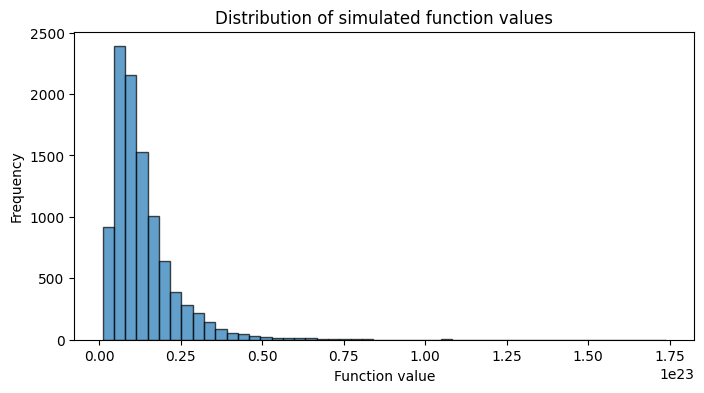

In [103]:
plt.figure(figsize=(8, 4))
plt.hist(results, bins=50, edgecolor="black", alpha=0.7)
plt.title("Distribution of simulated function values")
plt.xlabel("Function value")
plt.ylabel("Frequency")
plt.show()

## 7. Inspect a few simulated paths


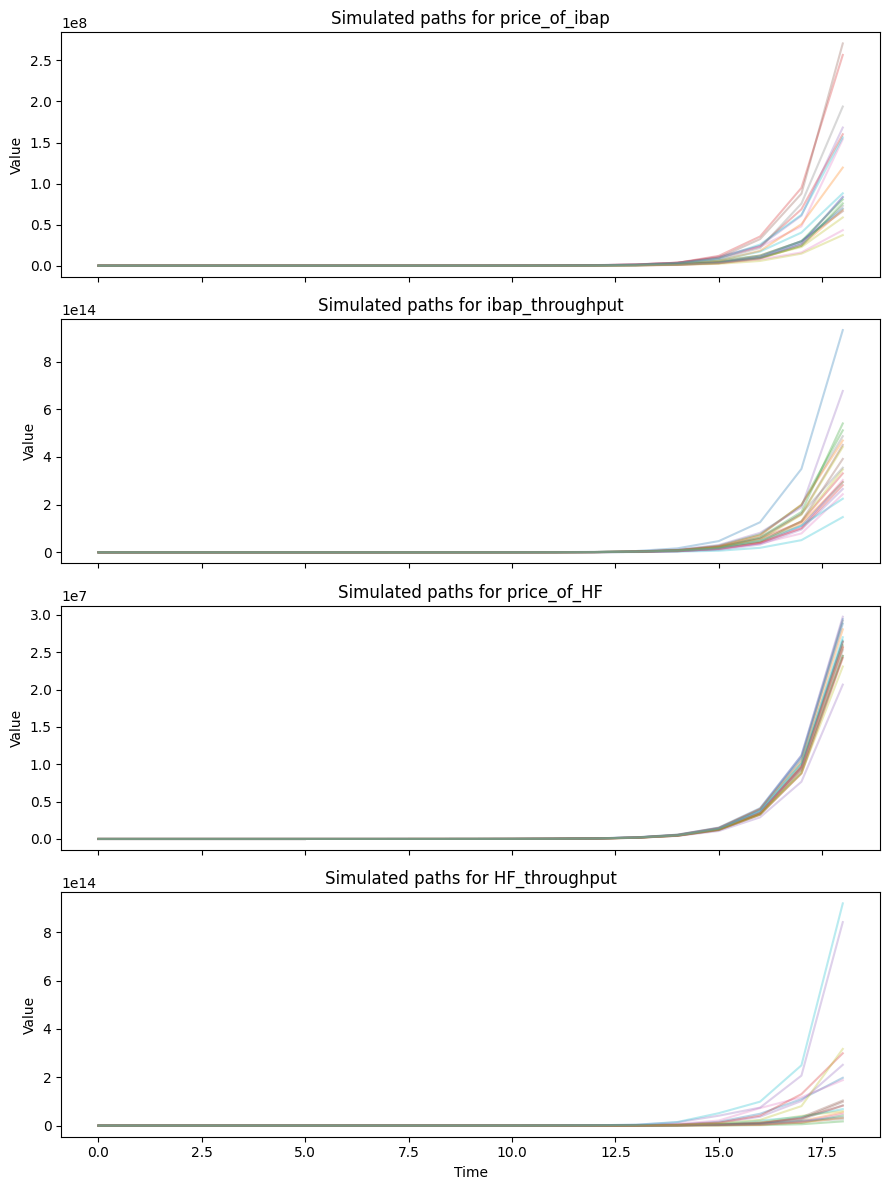

In [104]:
time_grid = np.linspace(0, T, n_steps + 1)

fig, axes = plt.subplots(n_assets, 1, figsize=(9, 3 * n_assets), sharex=True)
if n_assets == 1:
    axes = [axes]

for asset_idx, ax in enumerate(axes):
    driver_name = asset_names[asset_idx]
    for sim_idx in range(min(20, n_sims)):
        ax.plot(time_grid, simulated_paths[driver_name][sim_idx, :], alpha=0.3)
    ax.set_title(f"Simulated paths for {driver_name}")
    ax.set_ylabel("Value")

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Notes

- If your covariance matrix is estimated from historical log returns, it can be used directly as `cov_matrix`.
- If you instead have a correlation matrix and separate volatilities, build covariance as:
  `cov_matrix = np.outer(vols, vols) * corr_matrix`
- This version returns a dictionary of simulated paths keyed by driver name, so the DCF formula reads more naturally.
- If you prefer, I can also convert the simulator back to returning a single 3D NumPy array.


## 8. Joint simulation of all stochastic drivers

The earlier setup mirrors a single-factor style workflow. The cells below simulate all four stochastic drivers together in one Monte Carlo engine.

This version keeps:

- `price_of_ibap` and `price_of_HF` as GBM processes
- `ibap_throughput` and `HF_throughput` as level variables with normal shocks each period

If you later estimate correlations involving throughput as well, you can update the correlation matrix directly.


In [105]:
# Assumptions pulled from the univariate notebook
N_SIM = 10_000
n_periods = 18
dt = 1.0

# Separate starting values from drift rates.
# The original notebook estimated these price quantities in log space.
initial_log_ibap_price = 1.6467
drift_ibap_price = 0.0
sigma_ibap_price = 0.035

initial_log_HF_price = 0.0198
drift_HF_price = 0.0
sigma_HF_price = 0.0876

# Throughput starts at its baseline level and then evolves from the
# previous period using an arithmetic process on levels.
initial_ibap_throughput = 6_637_824.0
drift_ibap_throughput = 0.0
sigma_ibap_throughput = 576.0

initial_HF_throughput = 294_480.0
drift_HF_throughput = 0.0
sigma_HF_throughput = 121.34

raw_material_cost = 3_136_440.0
inflation = 0.02
discount_rate = 0.15

# Price covariance estimated earlier in your notebook work
price_covariance = np.array([
    [0.000804, 0.001032],
    [0.001032, 0.017536],
], dtype=float)

# Convert price covariance into price correlation for the joint shock matrix
price_vols = np.sqrt(np.diag(price_covariance))
price_corr = price_covariance / np.outer(price_vols, price_vols)
price_corr

array([[1.        , 0.27484409],
       [0.27484409, 1.        ]])

In [106]:
# Correlation matrix for the latent shocks driving all 4 variables
# By default, throughput shocks are independent until you estimate those correlations.
joint_corr = np.array([
    [1.0, 0.0, price_corr[0, 1], 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [price_corr[1, 0], 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
], dtype=float)

joint_corr

array([[1.        , 0.        , 0.27484409, 0.        ],
       [0.        , 1.        , 0.        , 0.        ],
       [0.27484409, 0.        , 1.        , 0.        ],
       [0.        , 0.        , 0.        , 1.        ]])

In [107]:
def simulate_all_stochastic_drivers(
    n_sims,
    n_periods,
    dt,
    initial_log_ibap_price,
    drift_ibap_price,
    sigma_ibap_price,
    initial_log_HF_price,
    drift_HF_price,
    sigma_HF_price,
    initial_ibap_throughput,
    drift_ibap_throughput,
    sigma_ibap_throughput,
    initial_HF_throughput,
    drift_HF_throughput,
    sigma_HF_throughput,
    joint_corr,
    random_seed=42,
):
    joint_corr = np.asarray(joint_corr, dtype=float)
    rng = np.random.default_rng(random_seed)

    latent_shocks = rng.multivariate_normal(
        mean=np.zeros(4),
        cov=joint_corr,
        size=(n_sims, n_periods),
    )

    z_ibap_price = latent_shocks[:, :, 0]
    z_ibap_throughput = latent_shocks[:, :, 1]
    z_HF_price = latent_shocks[:, :, 2]
    z_HF_throughput = latent_shocks[:, :, 3]

    ibap_log_returns = (
        (drift_ibap_price - 0.5 * sigma_ibap_price ** 2) * dt
        + sigma_ibap_price * np.sqrt(dt) * z_ibap_price
    )
    HF_log_returns = (
        (drift_HF_price - 0.5 * sigma_HF_price ** 2) * dt
        + sigma_HF_price * np.sqrt(dt) * z_HF_price
    )

    price_of_ibap = np.column_stack([
        np.full(n_sims, np.exp(initial_log_ibap_price)),
        np.exp(initial_log_ibap_price + np.cumsum(ibap_log_returns, axis=1)),
    ])
    price_of_HF = np.column_stack([
        np.full(n_sims, np.exp(initial_log_HF_price)),
        np.exp(initial_log_HF_price + np.cumsum(HF_log_returns, axis=1)),
    ])

    ibap_level_increments = (
        drift_ibap_throughput * dt
        + sigma_ibap_throughput * np.sqrt(dt) * z_ibap_throughput
    )
    HF_level_increments = (
        drift_HF_throughput * dt
        + sigma_HF_throughput * np.sqrt(dt) * z_HF_throughput
    )

    ibap_throughput = np.column_stack([
        np.full(n_sims, initial_ibap_throughput),
        initial_ibap_throughput + np.cumsum(ibap_level_increments, axis=1),
    ])
    HF_throughput = np.column_stack([
        np.full(n_sims, initial_HF_throughput),
        initial_HF_throughput + np.cumsum(HF_level_increments, axis=1),
    ])

    # Throughput should not go negative.
    ibap_throughput = np.maximum(ibap_throughput, 0.0)
    HF_throughput = np.maximum(HF_throughput, 0.0)

    return {
        "price_of_ibap": price_of_ibap,
        "ibap_throughput": ibap_throughput,
        "price_of_HF": price_of_HF,
        "HF_throughput": HF_throughput,
    }


In [108]:
joint_simulated_paths = simulate_all_stochastic_drivers(
    n_sims=N_SIM,
    n_periods=n_periods,
    dt=dt,
    initial_log_ibap_price=initial_log_ibap_price,
    drift_ibap_price=drift_ibap_price,
    sigma_ibap_price=sigma_ibap_price,
    initial_log_HF_price=initial_log_HF_price,
    drift_HF_price=drift_HF_price,
    sigma_HF_price=sigma_HF_price,
    initial_ibap_throughput=initial_ibap_throughput,
    drift_ibap_throughput=drift_ibap_throughput,
    sigma_ibap_throughput=sigma_ibap_throughput,
    initial_HF_throughput=initial_HF_throughput,
    drift_HF_throughput=drift_HF_throughput,
    sigma_HF_throughput=sigma_HF_throughput,
    joint_corr=joint_corr,
    random_seed=42,
)

for name, values in joint_simulated_paths.items():
    print(name, values.shape)


price_of_ibap (10000, 19)
ibap_throughput (10000, 19)
price_of_HF (10000, 19)
HF_throughput (10000, 19)


In [109]:
def calculate_joint_discounted_cash_flows(
    simulated_paths,
    raw_material_cost,
    inflation,
    discount_rate,
):
    price_of_ibap = simulated_paths["price_of_ibap"][:, 1:]
    ibap_throughput = simulated_paths["ibap_throughput"][:, 1:]
    price_of_HF = simulated_paths["price_of_HF"][:, 1:]
    HF_throughput = simulated_paths["HF_throughput"][:, 1:]

    # Cash flow is evaluated only on forecast periods 1..n_periods.
    t = np.arange(1, price_of_ibap.shape[1] + 1)

    revenue = price_of_ibap * ibap_throughput + price_of_HF * HF_throughput
    cost = raw_material_cost * (1 + inflation) ** t
    net_cash_flow = revenue - cost
    discounted_cash_flow = net_cash_flow / (1 + discount_rate) ** t

    return discounted_cash_flow


def calculate_joint_total_present_value(
    simulated_paths,
    raw_material_cost,
    inflation,
    discount_rate,
):
    discounted_cash_flows = calculate_joint_discounted_cash_flows(
        simulated_paths,
        raw_material_cost=raw_material_cost,
        inflation=inflation,
        discount_rate=discount_rate,
    )
    return discounted_cash_flows.sum(axis=1)


In [110]:
joint_discounted_cash_flows = calculate_joint_discounted_cash_flows(
    joint_simulated_paths,
    raw_material_cost=raw_material_cost,
    inflation=inflation,
    discount_rate=discount_rate,
)

joint_total_present_value = calculate_joint_total_present_value(
    joint_simulated_paths,
    raw_material_cost=raw_material_cost,
    inflation=inflation,
    discount_rate=discount_rate,
)

pd.Series(joint_total_present_value).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


count    1.000000e+04
mean     1.909858e+08
std      1.423493e+07
min      1.438417e+08
1%       1.599698e+08
5%       1.683413e+08
50%      1.903821e+08
95%      2.151986e+08
99%      2.257061e+08
max      2.562071e+08
dtype: float64

In [111]:
joint_dcf_table = pd.DataFrame(joint_discounted_cash_flows[:5])
joint_dcf_table.columns = [f"t={i}" for i in range(1, n_periods + 1)]
joint_dcf_table


,t=1,t=2,t=3,t=4,t=5,t=6,t=7,t=8,t=9,t=10,t=11,t=12,t=13,t=14,t=15,t=16,t=17,t=18
0,2.773629e+07,2.537719e+07,2.240635e+07,1.901983e+07,1.628460e+07,1.415138e+07,1.253918e+07,1.063124e+07,9.610300e+06,8.487782e+06,7.227408e+06,6.274221e+06,5.401251e+06,4.831803e+06,4.320814e+06,4.003629e+06,3.357979e+06,2.759291e+06
1,2.865217e+07,2.500574e+07,2.119677e+07,1.908726e+07,1.626775e+07,1.383754e+07,1.225599e+07,1.093415e+07,9.690693e+06,8.225023e+06,7.179891e+06,6.143983e+06,5.674069e+06,4.661478e+06,3.997234e+06,3.316540e+06,3.040801e+06,2.616717e+06
2,2.803171e+07,2.297053e+07,2.184281e+07,1.836922e+07,1.611389e+07,1.372552e+07,1.208141e+07,1.066895e+07,8.856473e+06,7.555306e+06,6.278694e+06,5.660818e+06,4.865404e+06,4.113827e+06,3.579128e+06,3.221642e+06,2.784870e+06,2.467260e+06
3,2.653985e+07,2.261435e+07,2.039608e+07,1.792616e+07,1.516378e+07,1.390218e+07,1.199177e+07,1.013125e+07,8.068463e+06,6.735411e+06,5.571391e+06,4.800676e+06,4.128986e+06,3.597358e+06,3.154147e+06,2.818539e+06,2.428810e+06,2.184582e+06
4,2.776226e+07,2.308582e+07,1.998438e+07,1.628472e+07,1.457454e+07,1.252893e+07,1.020257e+07,8.581567e+06,7.379377e+06,6.017986e+06,5.498049e+06,4.733041e+06,4.251480e+06,4.006642e+06,3.340540e+06,3.108307e+06,2.758126e+06,2.363309e+06


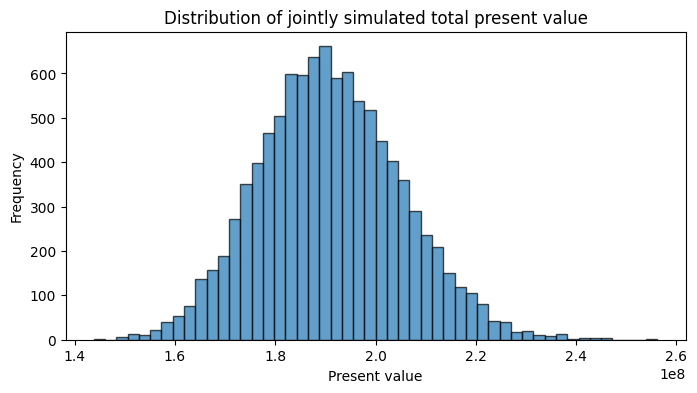

In [112]:
finite_joint_pv = joint_total_present_value[np.isfinite(joint_total_present_value)]

plt.figure(figsize=(8, 4))
plt.hist(finite_joint_pv, bins=50, edgecolor="black", alpha=0.7)
plt.title("Distribution of jointly simulated total present value")
plt.xlabel("Present value")
plt.ylabel("Frequency")
plt.show()


## 9. Plot the simulated joint paths

These cells plot the paths stored in `joint_simulated_paths` for each stochastic driver.


In [113]:
joint_driver_names = [
    "price_of_ibap",
    "ibap_throughput",
    "price_of_HF",
    "HF_throughput",
]

joint_time_grid = np.arange(0, n_periods + 1)
n_paths_to_plot = 20


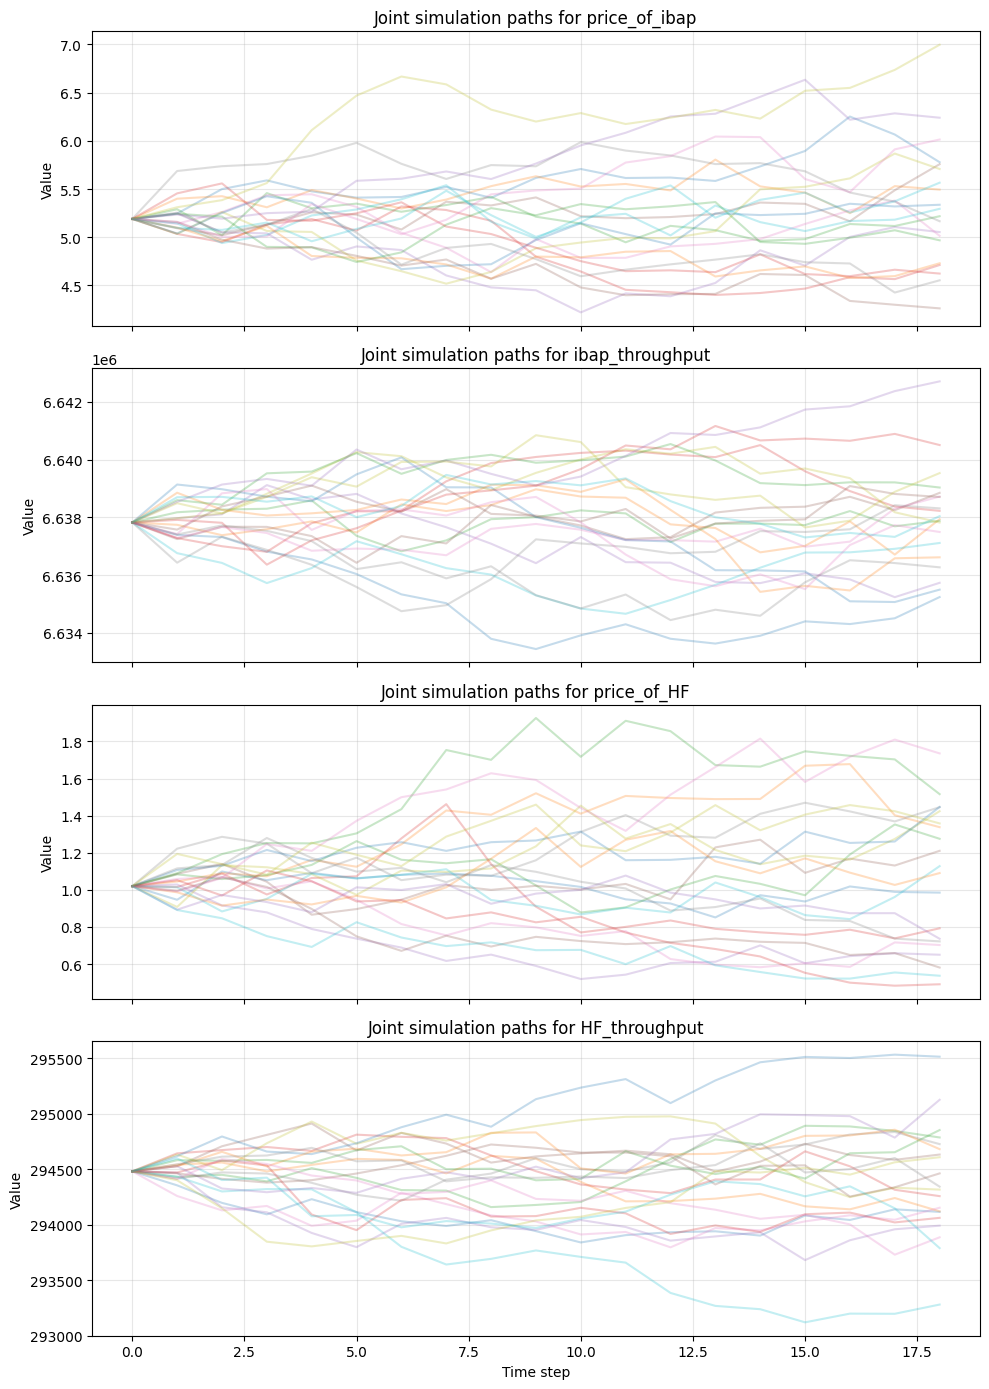

In [117]:
fig, axes = plt.subplots(len(joint_driver_names), 1, figsize=(10, 3.5 * len(joint_driver_names)), sharex=True)

for ax, driver_name in zip(axes, joint_driver_names):
    driver_paths = joint_simulated_paths[driver_name]
    for sim_idx in range(min(n_paths_to_plot, driver_paths.shape[0])):
        ax.plot(joint_time_grid, driver_paths[sim_idx, :], alpha=0.26)
    ax.set_title(f"Joint simulation paths for {driver_name}")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time step")
plt.tight_layout()
plt.show()


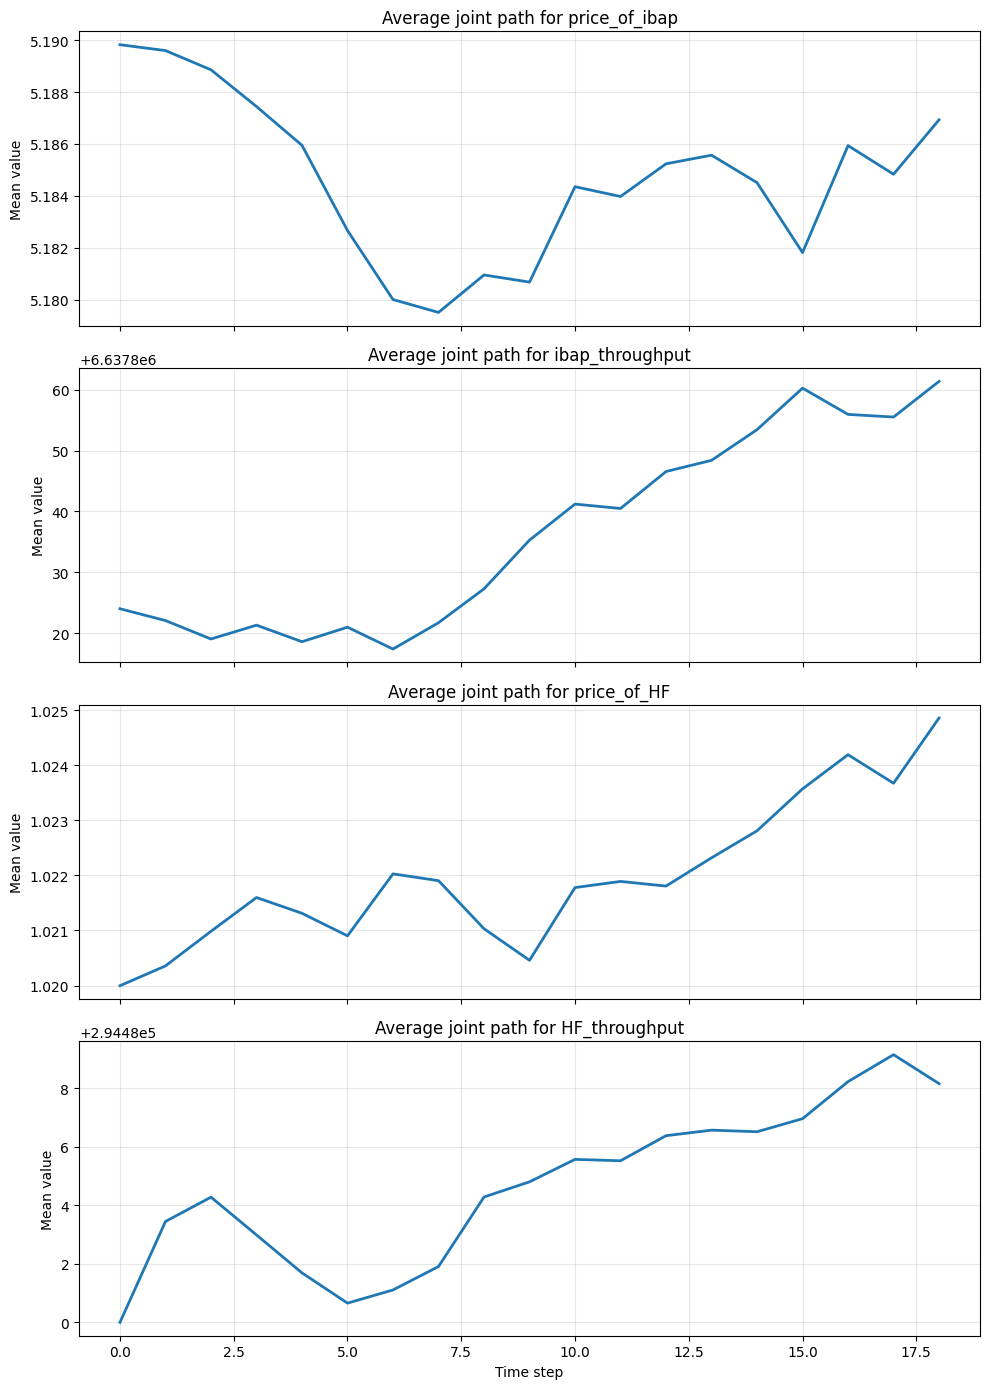

In [115]:
# Optional: plot the average path across all simulations for each driver.
fig, axes = plt.subplots(len(joint_driver_names), 1, figsize=(10, 3.5 * len(joint_driver_names)), sharex=True)

for ax, driver_name in zip(axes, joint_driver_names):
    mean_path = joint_simulated_paths[driver_name].mean(axis=0)
    ax.plot(joint_time_grid, mean_path, linewidth=2)
    ax.set_title(f"Average joint path for {driver_name}")
    ax.set_ylabel("Mean value")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time step")
plt.tight_layout()
plt.show()
